In [1]:
"""
02_full_analysis.ipynb
======================
Full five-year wind resource analysis for an offshore Sydney site using
ERA5 reanalysis data. Covers data loading, Weibull fitting, wind rose
generation, and AEP estimation for an NREL 5MW reference turbine.

Site:     -34.0°N, 151.75°E (Tasman Sea offshore)
Period:   2019–2023
Turbine:  NREL 5MW Reference (Jonkman et al., 2009)
"""

import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Add project root to path so src/ modules are importable
sys.path.insert(0, str(Path("..").resolve()))

# Project modules
from src.process_wind import (load_era5_multiyear,
                               add_temporal_features,
                               basic_diagnostics)
from src.weibull import (fit_weibull,
                          apply_hub_correction,
                          goodness_of_fit,
                          plot_weibull_fit)
from src.aep import (build_power_curve,
                      calculate_aep,
                      plot_aep_analysis)
from src.wind_rose import (directional_statistics,
                            print_directional_table,
                            plot_wind_rose,
                            plot_seasonal_roses)

# Load configuration
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Unpack frequently used config values for readability
SITE      = config["site"]
ERA5      = config["era5"]
TURBINE   = config["turbine"]
PATHS     = config["paths"]

FIGURES   = Path("..") / PATHS["figures"]
RESULTS   = Path("..") / PATHS["results"]
DATA_DIR  = Path("..") / PATHS["raw_data"]

print("Configuration loaded successfully")
print(f"  Site:    {SITE['name']} ({SITE['latitude']}°N, {SITE['longitude']}°E)")
print(f"  Period:  {ERA5['years'][0]}–{ERA5['years'][-1]}")
print(f"  Turbine: {TURBINE['name']}")

Configuration loaded successfully
  Site:    Sydney Offshore (-34.0°N, 151.75°E)
  Period:  2019–2023
  Turbine: NREL 5MW Reference


In [2]:
print("Loading ERA5 wind data...")
print("-" * 45)

df_all = load_era5_multiyear(
    years    = ERA5["years"],
    data_dir = str(DATA_DIR),
    lat      = SITE["latitude"],
    lon      = SITE["longitude"]
)

# Add temporal features for seasonal analysis
df_all = add_temporal_features(df_all)

print("\n--- Overall Diagnostics ---")
diags = basic_diagnostics(df_all)

Loading ERA5 wind data...
---------------------------------------------
  Loaded 2019: 8760 timesteps | Mean speed: 7.73 m/s
  Loaded 2020: 8784 timesteps | Mean speed: 8.16 m/s
  Loaded 2021: 8760 timesteps | Mean speed: 8.16 m/s
  Loaded 2022: 8760 timesteps | Mean speed: 8.12 m/s
  Loaded 2023: 8760 timesteps | Mean speed: 7.33 m/s

  Combined: 43824 total timesteps
  Period:   2019-01-01 00:00:00 to 2023-12-31 23:00:00
  Overall mean speed: 7.90 m/s

--- Overall Diagnostics ---
=== WIND SPEED DIAGNOSTICS ===
  Hours:              43,824
  Mean:               7.90 m/s
  Median:             7.53 m/s
  Std deviation:      3.90 m/s
  Max:                29.57 m/s
  % below cut-in:     9.4%
  % above rated:      15.3%
  % above cut-out:    0.0%
  Missing values:     0


In [3]:
print("Per-year wind speed summary:")
print(f"\n{'Year':<6} {'Hours':>7} {'Mean':>8} {'Median':>8} "
      f"{'Std':>7} {'Max':>7}")
print("-" * 48)

yearly = df_all.groupby(df_all.index.year)

for year, df_year in yearly:
    spd = df_year["wind_speed"]
    print(f"{year:<6} {len(spd):>7,} {spd.mean():>8.2f} "
          f"{spd.median():>8.2f} {spd.std():>7.2f} "
          f"{spd.max():>7.2f}")

Per-year wind speed summary:

Year     Hours     Mean   Median     Std     Max
------------------------------------------------
2019     8,760     7.73     7.23    3.90   23.21
2020     8,784     8.16     7.72    3.96   25.43
2021     8,760     8.16     7.93    4.04   29.57
2022     8,760     8.12     7.83    3.95   23.48
2023     8,760     7.33     6.94    3.57   26.00


In [4]:
print("Fitting Weibull distribution to combined 2019-2023 dataset...\n")

wind_speeds = df_all["wind_speed"].values

# Fit using MLE — floc=0 enforces two-parameter form
weibull_result = fit_weibull(
    wind_speeds,
    calm_threshold=ERA5["calm_threshold_ms"],
    verbose=True
)

# Apply hub height correction
weibull_hub = apply_hub_correction(
    weibull_result,
    z_ref  = ERA5["reference_height_m"],
    z_hub  = TURBINE["hub_height_m"],
    alpha  = TURBINE["shear_exponent"]
)

# Goodness of fit
gof = goodness_of_fit(wind_speeds, weibull_result)

Fitting Weibull distribution to combined 2019-2023 dataset...

=== WEIBULL FIT RESULTS ===
  Shape parameter  k:   2.1505
  Scale parameter  λ:   8.9487 m/s
  Observations used:    43,701
  Calm hours excluded:  123 (0.3%)
  Theoretical mean:     7.9251 m/s
  Observed mean:        7.9005 m/s
  Mean error:           0.0246 m/s
  Interpretation:       k=2.15 — moderately consistent

=== HUB HEIGHT CORRECTION ===
  Reference height:     100 m
  Hub height:           90 m
  Shear exponent α:     0.11
  Shear factor:         0.988477
  λ at 100m:          8.9487 m/s
  λ at 90m:           8.8456 m/s
  Mean at hub height:   7.8337 m/s

=== GOODNESS OF FIT ===
  KS statistic D:  0.0059
  p-value:         0.0922
  n observations:  43,701
  Result:          Cannot reject Weibull hypothesis (p > 0.05)


Figure saved: ..\outputs\figures\weibull_fit_5yr.png


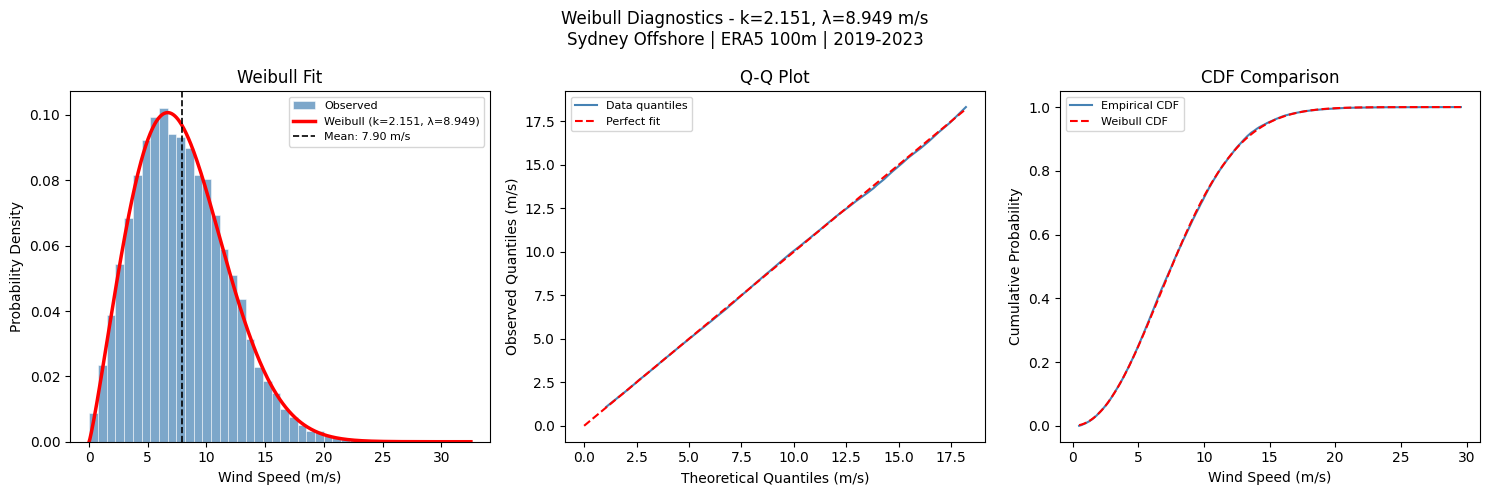

In [5]:
plot_weibull_fit(
    wind_speeds    = wind_speeds,
    weibull_result = weibull_result,
    title          = f"{SITE['name']} | ERA5 100m | 2019-2023",
    save_path      = str(FIGURES / "weibull_fit_5yr.png")
)

In [6]:
print("Per-year Weibull parameters:")
print(f"\n{'Year':<6} {'k':>8} {'λ 100m':>10} {'λ hub':>10} "
      f"{'Mean hub':>10} {'KS stat':>9} {'p-value':>9}")
print("-" * 68)

year_weibull = {}

for year, df_year in yearly:
    spd = df_year["wind_speed"].values

    # verbose=False suppresses per-function diagnostic output
    # keeping the loop output clean — just the summary table
    w = fit_weibull(
            spd,
            calm_threshold=ERA5["calm_threshold_ms"],
            verbose=False
        )
    w_hub = apply_hub_correction(
                w,
                z_ref  = ERA5["reference_height_m"],
                z_hub  = TURBINE["hub_height_m"],
                alpha  = TURBINE["shear_exponent"],
                verbose=False
            )
    gof_yr = goodness_of_fit(spd, w, verbose=False)

    year_weibull[year] = {
        "weibull":     w,
        "weibull_hub": w_hub,
        "gof":         gof_yr
    }

    print(f"{year:<6} {w['k']:>8.4f} {w['lam']:>10.4f} "
          f"{w_hub['lam_hub']:>10.4f} {w_hub['mean_hub']:>10.4f} "
          f"{gof_yr['ks_statistic']:>9.4f} {gof_yr['ks_pvalue']:>9.4f}")

# Summary statistics across years
k_vals    = [year_weibull[y]["weibull"]["k"]            for y in ERA5["years"]]
lam_vals  = [year_weibull[y]["weibull_hub"]["lam_hub"]  for y in ERA5["years"]]
mean_vals = [year_weibull[y]["weibull_hub"]["mean_hub"] for y in ERA5["years"]]

print("-" * 68)
print(f"{'Mean':<6} {np.mean(k_vals):>8.4f} {'':>10} "
      f"{np.mean(lam_vals):>10.4f} {np.mean(mean_vals):>10.4f}")
print(f"{'Std':<6} {np.std(k_vals):>8.4f} {'':>10} "
      f"{np.std(lam_vals):>10.4f} {np.std(mean_vals):>10.4f}")

Per-year Weibull parameters:

Year          k     λ 100m      λ hub   Mean hub   KS stat   p-value
--------------------------------------------------------------------
2019     2.1109     8.7630     8.6620     7.6717    0.0186    0.0048
2020     2.1928     9.2448     9.1383     8.0930    0.0100    0.3455
2021     2.1344     9.2372     9.1308     8.0864    0.0240    0.0001
2022     2.1799     9.1878     9.0819     8.0430    0.0086    0.5287
2023     2.1875     8.3057     8.2100     7.2709    0.0106    0.2734
--------------------------------------------------------------------
Mean     2.1611                8.8446     7.8330
Std      0.0325                0.3635     0.3219


=== AEP RESULTS ===
  Mean power:             1542.6 kW
  Gross AEP:              13.513 GWh/year
  Net AEP (95% avail):   12.838 GWh/year
  Gross capacity factor:  30.9%
  Net capacity factor:    29.3%
=== AEP RESULTS ===
  Mean power:             1676.1 kW
  Gross AEP:              14.682 GWh/year
  Net AEP (95% avail):   13.948 GWh/year
  Gross capacity factor:  33.5%
  Net capacity factor:    31.8%
=== AEP RESULTS ===
  Mean power:             1667.1 kW
  Gross AEP:              14.604 GWh/year
  Net AEP (95% avail):   13.874 GWh/year
  Gross capacity factor:  33.3%
  Net capacity factor:    31.7%
=== AEP RESULTS ===
  Mean power:             1659.9 kW
  Gross AEP:              14.541 GWh/year
  Net AEP (95% avail):   13.814 GWh/year
  Gross capacity factor:  33.2%
  Net capacity factor:    31.5%
=== AEP RESULTS ===
  Mean power:             1420.6 kW
  Gross AEP:              12.445 GWh/year
  Net AEP (95% avail):   11.823 GWh/year
  Gross capacity factor:  28.4%
  Net capacity fa

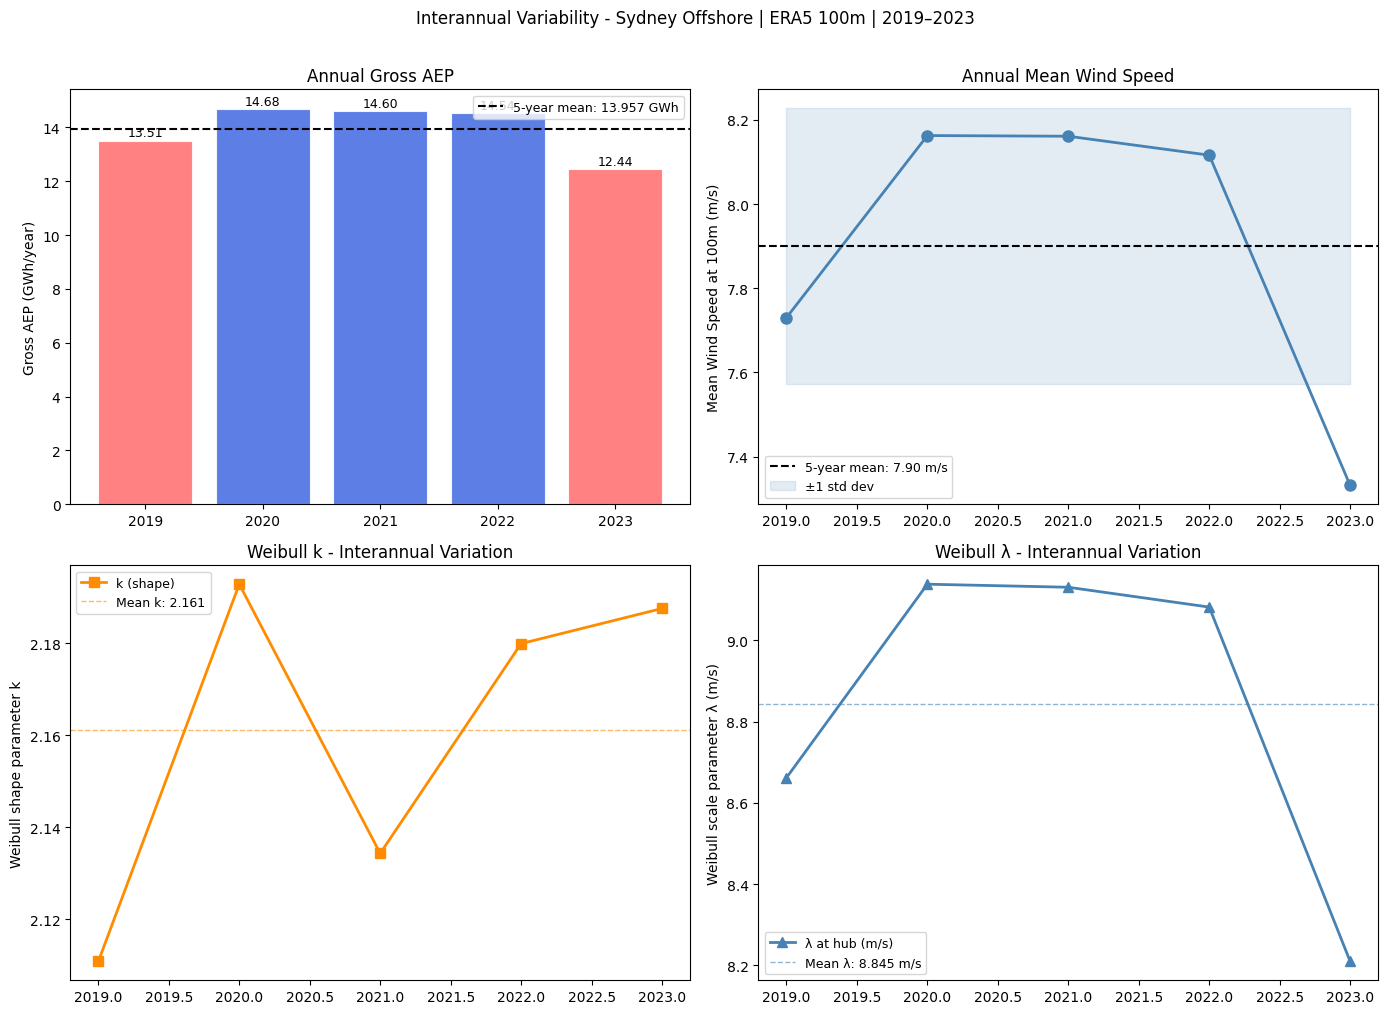


Interannual AEP variability:
  Mean gross AEP:      13.957 GWh/year
  Std deviation:       0.868 GWh/year
  Coeff. of variation: 6.2%


In [13]:
years_list  = list(year_weibull.keys())
gross_aeps  = []
mean_speeds = []
k_vals      = []
lam_vals    = []

# Build power curve once — reused for every year
power_fn = build_power_curve()

for year in years_list:
    w_hub = year_weibull[year]["weibull_hub"]
    aep   = calculate_aep(
                k_hub          = w_hub["k_hub"],
                lam_hub        = w_hub["lam_hub"],
                power_fn       = power_fn,
                availability   = TURBINE["availability"],
                rated_power_mw = TURBINE["rated_power_mw"]
            )
    gross_aeps.append(aep["gross_aep_gwh"])
    mean_speeds.append(year_weibull[year]["weibull"]["observed_mean"])
    k_vals.append(w_hub["k_hub"])
    lam_vals.append(w_hub["lam_hub"])

mean_aep   = np.mean(gross_aeps)
mean_speed = np.mean(mean_speeds)
cov        = np.std(gross_aeps) / mean_aep * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Gross AEP by year ---
ax      = axes[0, 0]
colours = ["#4169E1" if v >= mean_aep else "#FF6B6B"
           for v in gross_aeps]
bars    = ax.bar(years_list, gross_aeps, color=colours,
                 edgecolor="white", linewidth=0.8, alpha=0.85)
ax.axhline(mean_aep, color="black", linewidth=1.5, linestyle="--",
           label=f"5-year mean: {mean_aep:.3f} GWh")
for bar, val in zip(bars, gross_aeps):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Gross AEP (GWh/year)")
ax.set_title("Annual Gross AEP")
ax.legend(fontsize=9)

# --- Panel 2: Mean wind speed by year ---
ax = axes[0, 1]
ax.plot(years_list, mean_speeds, marker="o", markersize=8,
        linewidth=2.0, color="steelblue")
ax.axhline(mean_speed, color="black", linewidth=1.5, linestyle="--",
           label=f"5-year mean: {mean_speed:.2f} m/s")
ax.fill_between(years_list,
                mean_speed - np.std(mean_speeds),
                mean_speed + np.std(mean_speeds),
                alpha=0.15, color="steelblue", label="±1 std dev")
ax.set_ylabel("Mean Wind Speed at 100m (m/s)")
ax.set_title("Annual Mean Wind Speed")
ax.legend(fontsize=9)

# --- Panel 3: Weibull k by year ---
ax = axes[1, 0]
ax.plot(years_list, k_vals, marker="s", markersize=7,
        linewidth=2.0, color="darkorange", label="k (shape)")
ax.axhline(np.mean(k_vals), color="darkorange",
           linewidth=1.0, linestyle="--", alpha=0.6,
           label=f"Mean k: {np.mean(k_vals):.3f}")
ax.set_ylabel("Weibull shape parameter k")
ax.set_title("Weibull k - Interannual Variation")
ax.legend(fontsize=9)

# --- Panel 4: Weibull λ by year ---
ax = axes[1, 1]
ax.plot(years_list, lam_vals, marker="^", markersize=7,
        linewidth=2.0, color="steelblue", label="λ at hub (m/s)")
ax.axhline(np.mean(lam_vals), color="steelblue",
           linewidth=1.0, linestyle="--", alpha=0.6,
           label=f"Mean λ: {np.mean(lam_vals):.3f} m/s")
ax.set_ylabel("Weibull scale parameter λ (m/s)")
ax.set_title("Weibull λ - Interannual Variation")
ax.legend(fontsize=9)

plt.suptitle(
    f"Interannual Variability - {SITE['name']} | "
    f"ERA5 100m | {ERA5['years'][0]}–{ERA5['years'][-1]}",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(str(FIGURES / "interannual_variability.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\nInterannual AEP variability:")
print(f"  Mean gross AEP:      {mean_aep:.3f} GWh/year")
print(f"  Std deviation:       {np.std(gross_aeps):.3f} GWh/year")
print(f"  Coeff. of variation: {cov:.1f}%")

Computing five-year aggregate AEP...

=== AEP RESULTS ===
  Mean power:             1594.8 kW
  Gross AEP:              13.971 GWh/year
  Net AEP (95% avail):   13.272 GWh/year
  Gross capacity factor:  31.9%
  Net capacity factor:    30.3%
Figure saved: ..\outputs\figures\aep_analysis_5yr.png


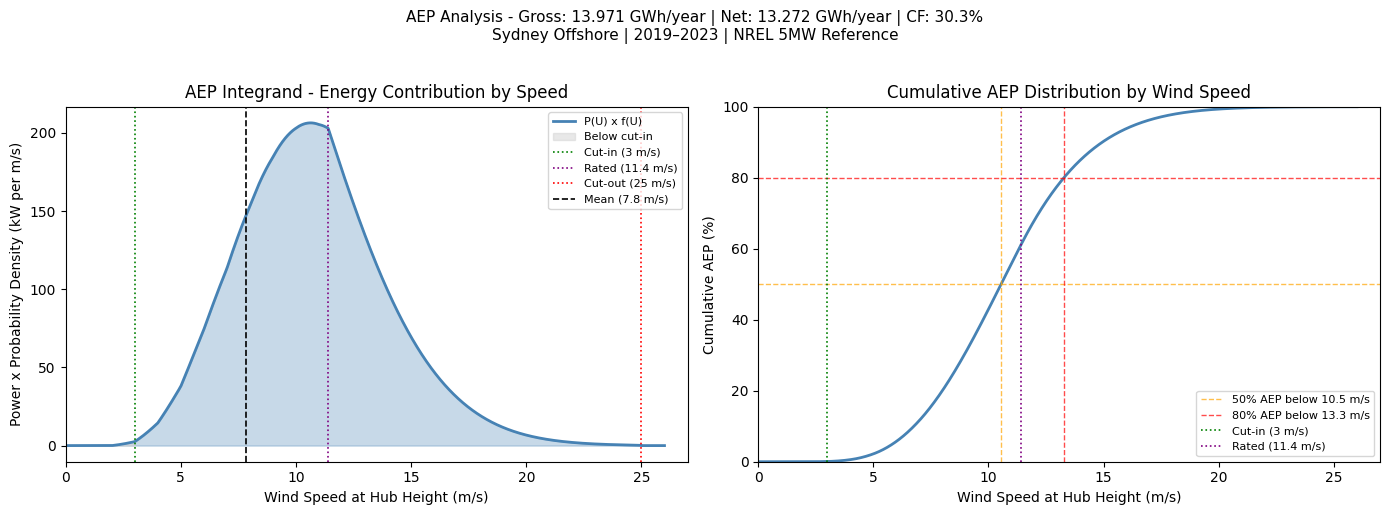

In [8]:
print("Computing five-year aggregate AEP...\n")

# Five year Weibull fit already computed in Cell 4 as weibull_hub
# Power curve already built in Cell 7 as power_fn
aep_result = calculate_aep(
    k_hub          = weibull_hub["k_hub"],
    lam_hub        = weibull_hub["lam_hub"],
    power_fn       = power_fn,
    availability   = TURBINE["availability"],
    rated_power_mw = TURBINE["rated_power_mw"]
)

plot_aep_analysis(
    k_hub      = weibull_hub["k_hub"],
    lam_hub    = weibull_hub["lam_hub"],
    power_fn   = power_fn,
    aep_result = aep_result,
    title      = (f"{SITE['name']} | "
                  f"{ERA5['years'][0]}–{ERA5['years'][-1]} | "
                  f"{TURBINE['name']}"),
    save_path  = str(FIGURES / "aep_analysis_5yr.png")
)

C:\Users\Aidan\OneDrive\Documents\Engineering Projects\wind-data-analysis\src\wind_rose.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved: ..\outputs\figures\wind_rose_5yr.png


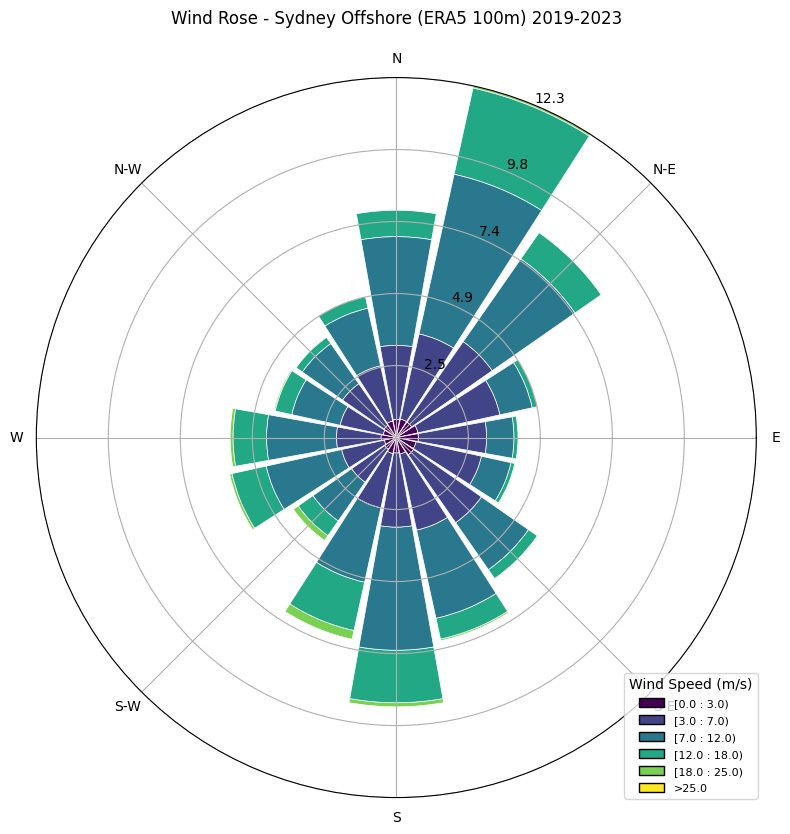

=== DIRECTIONAL ANALYSIS ===
Sector  Centre     Freq   Mean U   Max U   > Rated   Energy
--------------------------------------------------------------
N         0.0°      7.7%     7.90    19.08      11.6%     6.6%  █████
NNE      22.5°     12.3%     9.22    21.36      25.1%    16.5%  ████████
NE       45.0°      8.5%     7.69    21.34      13.0%     7.2%  █████
ENE      67.5°      4.9%     5.72    22.74       3.8%     1.9%  ███
E        90.0°      4.2%     5.67    25.43       3.7%     1.9%  ██
ESE     112.5°      4.2%     5.89    24.61       4.0%     2.0%  ██
SE      135.0°      5.9%     6.60    20.44       6.6%     3.4%  ███
SSE     157.5°      7.1%     7.61    21.96      11.1%     5.8%  ████
S       180.0°      9.2%     8.89    23.21      21.0%    11.6%  ██████
SSW     202.5°      7.0%     9.35    23.48      28.3%    11.6%  ████
SW      225.0°      4.3%     8.36    28.39      19.4%     6.1%  ██
WSW     247.5°      5.8%     8.97    29.57      22.2%     7.9%  ███
W       270.0°      5

In [15]:
plot_wind_rose(
    df_all,
    title     = (f"Wind Rose - {SITE['name']} (ERA5 100m) "
                 f"{ERA5['years'][0]}-{ERA5['years'][-1]}"),
    save_path = str(FIGURES / "wind_rose_5yr.png")
)

# Directional statistics table
df_sectors = directional_statistics(df_all)
print_directional_table(df_sectors)

Figure saved: ..\outputs\figures\seasonal_roses_5yr.png


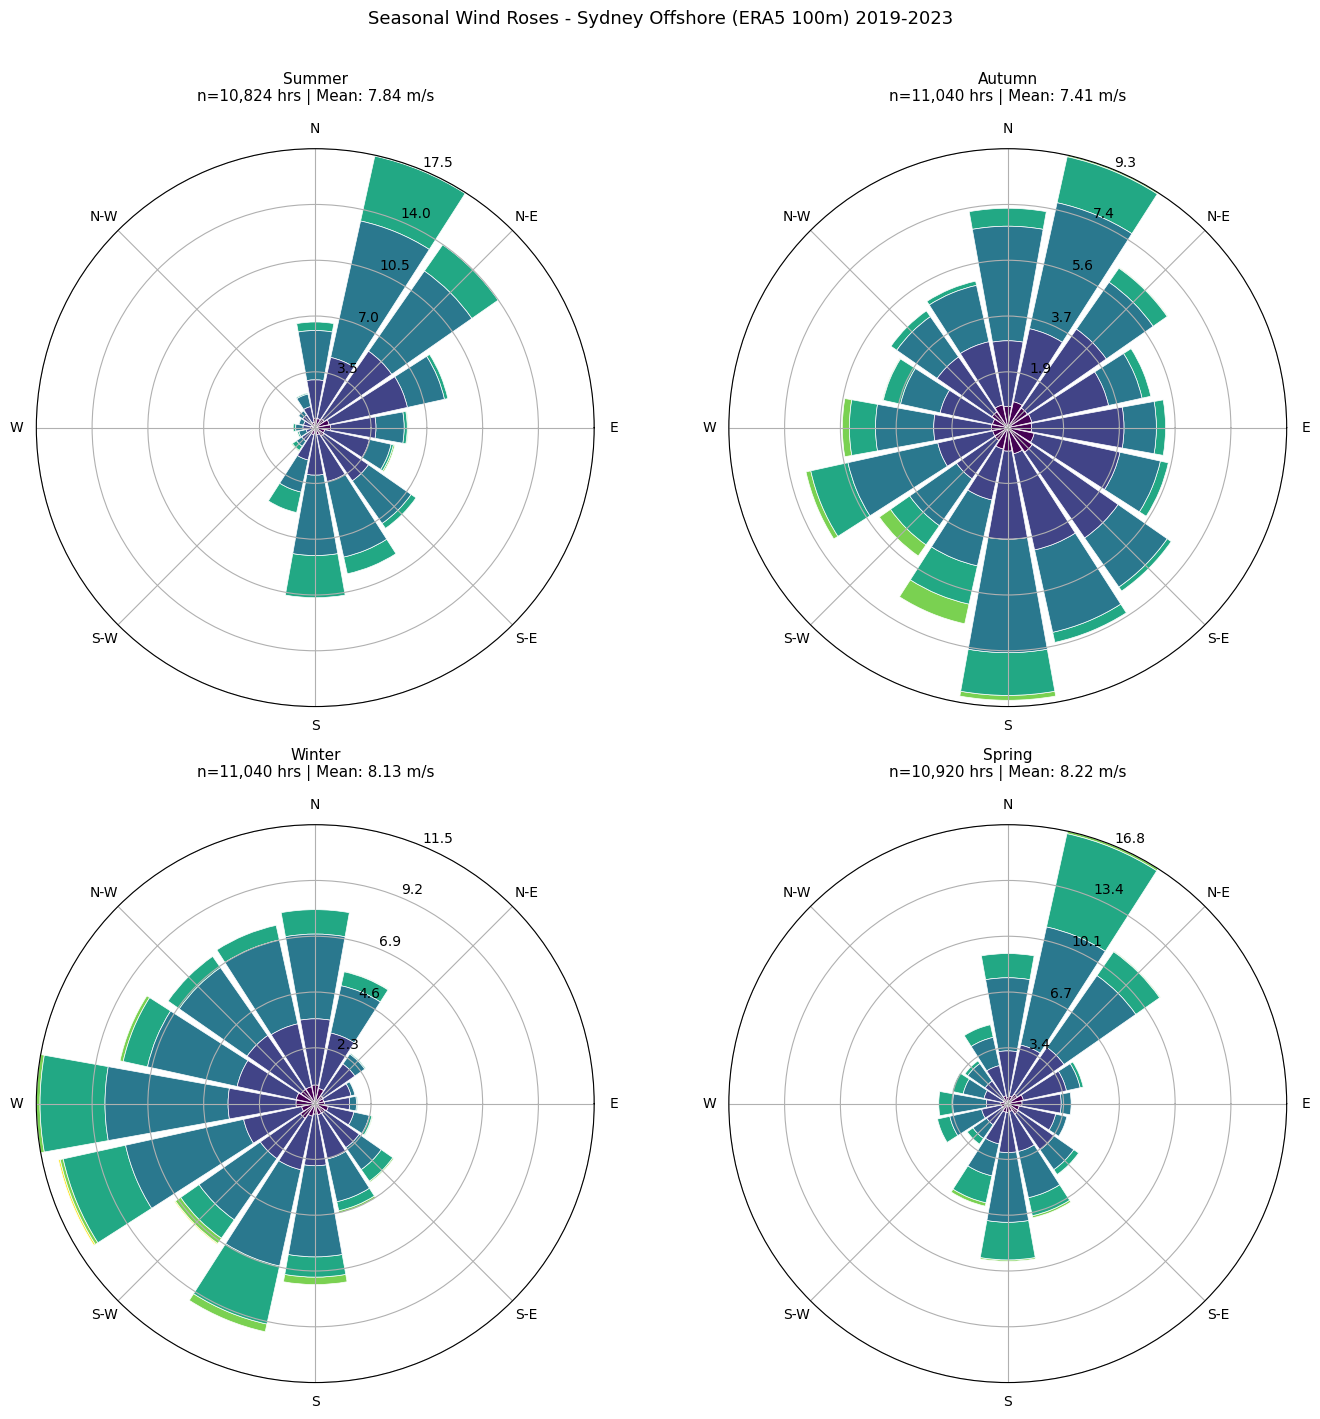

In [16]:
plot_seasonal_roses(
    df_all,
    title     = (f"Seasonal Wind Roses - {SITE['name']} "
                 f"(ERA5 100m) "
                 f"{ERA5['years'][0]}-{ERA5['years'][-1]}"),
    save_path = str(FIGURES / "seasonal_roses_5yr.png")
)

In [11]:
print("=" * 60)
print("   WIND RESOURCE ASSESSMENT — RESULTS SUMMARY")
print("=" * 60)

print(f"\n  Site:          {SITE['name']}")
print(f"  Coordinates:   {SITE['latitude']}°N, "
      f"{SITE['longitude']}°E")
print(f"  Data source:   ERA5 reanalysis (ECMWF)")
print(f"  Period:        {ERA5['years'][0]}–{ERA5['years'][-1]} "
      f"({len(ERA5['years'])} years)")
print(f"  Observations:  {diags['n_hours']:,} hourly timesteps")

print(f"\n  --- Wind Resource ---")
print(f"  Mean speed (100m):     {diags['mean_ms']:.2f} m/s")
print(f"  Mean speed (hub):      {weibull_hub['mean_hub']:.2f} m/s")
print(f"  Weibull k:             {weibull_hub['k_hub']:.4f}")
print(f"  Weibull λ (hub):       {weibull_hub['lam_hub']:.4f} m/s")

dominant = df_sectors.loc[df_sectors["energy_pct"].idxmax()]
print(f"  Dominant direction:    {dominant['label']} "
      f"({dominant['energy_pct']:.1f}% of energy flux)")

print(f"\n  --- Turbine ---")
print(f"  Model:                 {TURBINE['name']}")
print(f"  Rated power:           {TURBINE['rated_power_mw']} MW")
print(f"  Hub height:            {TURBINE['hub_height_m']} m")
print(f"  Source:                {TURBINE['source']}")

print(f"\n  --- AEP Estimate ---")
print(f"  Gross AEP:             "
      f"{aep_result['gross_aep_gwh']:.3f} GWh/year")
print(f"  Net AEP:               "
      f"{aep_result['net_aep_gwh']:.3f} GWh/year")
print(f"  Gross capacity factor: "
      f"{aep_result['capacity_factor_gross']:.1%}")
print(f"  Net capacity factor:   "
      f"{aep_result['capacity_factor_net']:.1%}")

print(f"\n  --- Key Assumptions ---")
print(f"  Availability factor:   {TURBINE['availability']:.0%}")
print(f"  Shear exponent:        {TURBINE['shear_exponent']} "
      f"(offshore)")
print(f"  Wake losses:           Not modelled (single turbine)")
print(f"  Electrical losses:     Not modelled")
print(f"  Mesoscale correction:  Not applied (ERA5 direct)")
print(f"  Vertical extrapolation: Power law "
      f"({ERA5['reference_height_m']:.0f}m → "
      f"{TURBINE['hub_height_m']:.0f}m)")

print(f"\n  --- Interannual Variability ---")
print(f"  Annual AEP range:      "
      f"{min(gross_aeps):.3f}–{max(gross_aeps):.3f} GWh/year")
print(f"  Std deviation:         "
      f"{np.std(gross_aeps):.3f} GWh/year")
print(f"  Coeff. of variation:   {cov:.1f}%")
print("=" * 60)

   WIND RESOURCE ASSESSMENT — RESULTS SUMMARY

  Site:          Sydney Offshore
  Coordinates:   -34.0°N, 151.75°E
  Data source:   ERA5 reanalysis (ECMWF)
  Period:        2019–2023 (5 years)
  Observations:  43,824 hourly timesteps

  --- Wind Resource ---
  Mean speed (100m):     7.90 m/s
  Mean speed (hub):      7.83 m/s
  Weibull k:             2.1505
  Weibull λ (hub):       8.8456 m/s
  Dominant direction:    NNE (16.5% of energy flux)

  --- Turbine ---
  Model:                 NREL 5MW Reference
  Rated power:           5.0 MW
  Hub height:            90.0 m
  Source:                Jonkman et al. (2009) NREL/TP-500-38060

  --- AEP Estimate ---
  Gross AEP:             13.971 GWh/year
  Net AEP:               13.272 GWh/year
  Gross capacity factor: 31.9%
  Net capacity factor:   30.3%

  --- Key Assumptions ---
  Availability factor:   95%
  Shear exponent:        0.11 (offshore)
  Wake losses:           Not modelled (single turbine)
  Electrical losses:     Not modelled
  M